# B1: Dummy multi properties predictor - MW, logP, TPSA

## Goal
Learn how to set up the training, validation, and testing of a dummy 4-layer MLP for predicting the MW, logP, and TPSA.

## Dataset
ESOL — 1,128 molecules with experimental solubility values.
Available via DeepChem or direct CSV.

## Pipeline
1. Load ESOL dataset
2. Generate RDKit descriptors (all available features per molecule)
3. Train/val/test split (80/10/10) [Drop MW, logP, TPSA from input features and carry over to Ground truth]
4. Normalise both input features and predictions using training set statistics
5. Train MLP
6. Evaluate: RMSE
7. Scatter plot: predicted vs actual

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv"
df = pd.read_csv(url)
print(df.shape)
print(df.head())
print(df.columns.tolist())

(1128, 10)
  Compound ID  ESOL predicted log solubility in mols per litre  \
0   Amigdalin                                           -0.974   
1    Fenfuram                                           -2.885   
2      citral                                           -2.579   
3      Picene                                           -6.618   
4   Thiophene                                           -2.232   

   Minimum Degree  Molecular Weight  Number of H-Bond Donors  Number of Rings  \
0               1           457.432                        7                3   
1               1           201.225                        1                2   
2               1           152.237                        0                0   
3               2           278.354                        0                5   
4               2            84.143                        0                1   

   Number of Rotatable Bonds  Polar Surface Area  \
0                          7              202.32   
1

In [3]:
'''
Pipeline:
SMILES -> RDKit -> descriptors -> normalize -> MLP
'''

# Step 1: Grab Compound ID & Smiles
compounds = df[["Compound ID", "smiles", "measured log solubility in mols per litre"]].copy()
print(compounds.head())

# Step 2: Convert SMILES to RDKit Molecules (drop rows with invalid SMILES)
try:
    from rdkit import Chem
except ImportError:
    print("RDKit is not installed. Please install it to proceed.")
    !pip install rdkit
    from rdkit import Chem

def smiles_to_rdkit_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: # None is returned silently for invalid SMILES
        return "Error"
    return mol

# Insert a new column "rdkit_mol" by applying the conversion function to the "smiles" column
compounds["rdkit_mol"] = compounds["smiles"].apply(smiles_to_rdkit_mol)
error_compounds = compounds[compounds["rdkit_mol"] == "Error"]
print(f"Number of compounds with invalid SMILES: {len(error_compounds)}")
valid_compounds = compounds[compounds["rdkit_mol"] != "Error"]

  Compound ID                                             smiles  \
0   Amigdalin  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...   
1    Fenfuram                             Cc1occc1C(=O)Nc2ccccc2   
2      citral                               CC(C)=CCCC(C)=CC(=O)   
3      Picene                 c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43   
4   Thiophene                                            c1ccsc1   

   measured log solubility in mols per litre  
0                                      -0.77  
1                                      -3.30  
2                                      -2.06  
3                                      -7.87  
4                                      -1.33  
Number of compounds with invalid SMILES: 0


In [4]:
# Step 3: Compute descriptors for valid compounds
from rdkit.Chem.Descriptors import CalcMolDescriptors
import numpy as np
'''
Considerations: 
- Not all descriptors available for a given molecule
- Need to ensure consistency across all datasets
'''
desc_list = []
for mol in valid_compounds["rdkit_mol"]:
    desc = CalcMolDescriptors(mol, missingVal=np.nan)
    desc_list.append(desc)
   

# Convert list of descriptors to a DataFrame with descriptor names as columns
desc_df = pd.DataFrame(desc_list)
print(desc_df.head())
print(f"Shape before dropping: {desc_df.shape}")
print(f"Columns with NaN: {desc_df.isna().any().sum()}")
print([c for c in desc_df.columns if c in ['MolWt', 'MolLogP', 'TPSA', 'ExactMolWt']])

   MaxAbsEStateIndex  MaxEStateIndex  MinAbsEStateIndex  MinEStateIndex  \
0          10.253329       10.253329           0.486602       -1.701605   
1          11.724911       11.724911           0.145880       -0.145880   
2          10.020498       10.020498           0.845090        0.845090   
3           2.270278        2.270278           1.301055        1.301055   
4           2.041667        2.041667           1.712963        1.712963   

        qed        SPS    MolWt  HeavyAtomMolWt  ExactMolWt  \
0  0.217518  41.062500  457.432         430.216  457.158411   
1  0.811283   9.933333  201.225         190.137  201.078979   
2  0.343706  11.000000  152.237         136.109  152.120115   
3  0.291526  11.636364  278.354         264.242  278.109550   
4  0.448927   8.000000   84.143          80.111   84.003371   

   NumValenceElectrons  ...  fr_sulfide  fr_sulfonamd  fr_sulfone  \
0                  178  ...           0             0           0   
1                   76  ...     

In [5]:
# Step 4: drop columns with any NaN
desc_df = desc_df.dropna(axis=1)
print(f"Shape after dropping: {desc_df.shape}")

# Step 5: Extract target
X = desc_df.drop(columns=["MolWt", "ExactMolWt", "TPSA", "MolLogP"]).values
y = desc_df[["MolWt", "TPSA", "MolLogP"]].values
print(f"X shape: {X.shape}, y shape: {y.shape}")

Shape after dropping: (1128, 217)
X shape: (1128, 213), y shape: (1128, 3)


In [6]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Second split: Split temp into 2: 0.5 x 20% temp = 10% test + 10% val
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (902, 213), Val: (113, 213), Test: (113, 213)


In [7]:
# Normalize input features using training set statistics

# Step 1: Compute std from training set
std_input = X_train.std(axis=0)
print(f"Std shape: {std_input.shape}")

# Avoid descriptors with zero variance (std=0) to prevent division by zero
zero_std_mask = std_input == 0
print(f"Number of descriptors with zero std: {zero_std_mask.sum()}")

# Drop zero variance descriptors from all datasets
X_train_non_zero_var = X_train[:, ~zero_std_mask]
X_val_non_zero_var = X_val[:, ~zero_std_mask]
X_test_non_zero_var = X_test[:, ~zero_std_mask]

mean_input_non_zero_var = X_train_non_zero_var.mean(axis=0)
std_input_non_zero_var = X_train_non_zero_var.std(axis=0)
print(f"Mean shape after dropping zero variance: {mean_input_non_zero_var.shape}, Std shape after dropping zero variance: {std_input_non_zero_var.shape}")


Std shape: (213,)
Number of descriptors with zero std: 19
Mean shape after dropping zero variance: (194,), Std shape after dropping zero variance: (194,)


In [8]:
# Step 2: Normalize training, validation, and test sets using training set mean and std
X_train_norm = (X_train_non_zero_var - mean_input_non_zero_var) / std_input_non_zero_var
X_val_norm = (X_val_non_zero_var - mean_input_non_zero_var) / std_input_non_zero_var
X_test_norm = (X_test_non_zero_var - mean_input_non_zero_var) / std_input_non_zero_var

print(f"Train mean (should be ~0): {X_train_norm.mean(axis=0).mean():.4f}")
print(f"Train std (should be ~1): {X_train_norm.std(axis=0).mean():.4f}")
print(f"dtype: {X_train_norm.dtype}")

Train mean (should be ~0): 0.0000
Train std (should be ~1): 1.0000
dtype: float64


In [9]:
# Normalize target using training set statistics

# Step 1: Compute std from training set
std_target = y_train.std(axis=0)
print(f"Std shape: {std_target.shape}")

# Avoid descriptors with zero variance (std=0) to prevent division by zero
zero_std_mask = std_target == 0
print(f"Number of targets with zero std: {zero_std_mask.sum()}")

# Drop zero variance descriptors from all datasets
y_train_non_zero_var = y_train[:, ~zero_std_mask]
y_val_non_zero_var = y_val[:, ~zero_std_mask]
y_test_non_zero_var = y_test[:, ~zero_std_mask]

mean_target_non_zero_var = y_train_non_zero_var.mean(axis=0)
std_target_non_zero_var = y_train_non_zero_var.std(axis=0)
print(f"Mean shape after dropping zero variance: {mean_target_non_zero_var.shape}, Std shape after dropping zero variance: {std_target_non_zero_var.shape}")


Std shape: (3,)
Number of targets with zero std: 0
Mean shape after dropping zero variance: (3,), Std shape after dropping zero variance: (3,)


In [10]:
# Step 2: Normalize training, validation, and test sets using training set mean and std
y_train_norm = (y_train_non_zero_var - mean_target_non_zero_var) / std_target_non_zero_var
y_val_norm = (y_val_non_zero_var - mean_target_non_zero_var) / std_target_non_zero_var
y_test_norm = (y_test_non_zero_var - mean_target_non_zero_var) / std_target_non_zero_var

print(f"Train mean (should be ~0): {y_train_norm.mean(axis=0).mean():.4f}")
print(f"Train std (should be ~1): {y_train_norm.std(axis=0).mean():.4f}")
print(f"dtype: {y_train_norm.dtype}")

Train mean (should be ~0): 0.0000
Train std (should be ~1): 1.0000
dtype: float64


In [11]:
# Convert Datasets to PyTorch tensors
import torch

X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_norm, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_norm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_norm, dtype=torch.float32)

print(f"X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")

X_train: torch.Size([902, 194]), y_train: torch.Size([902, 3])


In [12]:
'''
Wrap datasets in PyTorch Dataset and DataLoader for batching and shuffling during training, validation, and testing
'''

from torch.utils.data import Dataset, DataLoader

class MoleculeDataset(Dataset):
    def __init__(self, descriptors, labels):
        self.descriptors = descriptors
        self.labels = labels
    
    def __len__(self):
        return len(self.descriptors)
    
    def __getitem__(self, idx):
        return self.descriptors[idx], self.labels[idx]

# Create dataset and dataloader
X_train_dataset = MoleculeDataset(X_train_tensor, y_train_tensor)
X_val_dataset = MoleculeDataset(X_val_tensor, y_val_tensor)
X_test_dataset = MoleculeDataset(X_test_tensor, y_test_tensor)

X_train_loader = DataLoader(X_train_dataset, batch_size=32, shuffle=True)
X_val_loader = DataLoader(X_val_dataset, batch_size=32, shuffle=False)
X_test_loader = DataLoader(X_test_dataset, batch_size=32, shuffle=False)


In [13]:
'''
Input dimension: 194
Architecture from day1_MLP_architecture.ipynb: 3 hidden layers (512, 256, 128) with BatchNorm, ReLU, Dropout(0.2)
Output: 3 neurons

Optimizer: Use Adam this time — on a dataset this size and complexity Adam will outperform SGD. Learning rate 0.001.
'''

import math

import torch.nn as nn

full_model = nn.Sequential(
    # --- Block 1 ---
    # Projects 194 raw input features (data, not neurons) into 512 neurons
    nn.Linear(194, 512),
    nn.BatchNorm1d(512),  # normalises the 512 neuron outputs
    nn.ReLU(),            # introduces non-linearity
    nn.Dropout(0.2),      # randomly deactivates 20% of neurons during training

    # --- Block 2 ---
    # Hidden layer: 512 neurons → 256 neurons
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.2),

    # --- Block 3 ---
    # Hidden layer: 256 neurons → 128 neurons
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.2),

    # --- Output ---
    # No activation, BatchNorm, or Dropout — raw value for regression
    nn.Linear(128, 3)
)


# loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(full_model.parameters(), lr=0.001)

torch.manual_seed(42)  # For reproducibility
num_epochs = 100
for epoch in range(num_epochs):
    # --- Training loop ---
    full_model.train()  # Set model to training mode
    train_loss = 0
    for batch in X_train_loader:
        batch_X, batch_y = batch
        optimizer.zero_grad()  # Clear gradients
        outputs = full_model(batch_X) # Forward pass
        loss = criterion(outputs, batch_y)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        train_loss += loss.item()   # Accumulate loss
    # --- Validation ---
    full_model.eval()  # Set model to evaluation mode
    val_loss = 0
    with torch.no_grad():  # No need to compute gradients during validation
        for batch in X_val_loader:
            batch_X, batch_y = batch
            outputs = full_model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {train_loss/len(X_train_loader):.4f}, Val Loss: {val_loss/len(X_val_loader):.4f}")
        print(f"Train RMSE (normalised): {math.sqrt(train_loss/len(X_train_loader)):.4f}")
        print(f"Val RMSE (normalised): {math.sqrt(val_loss/len(X_val_loader)):.4f}")
    

Epoch 0, Loss: 0.3267, Val Loss: 0.0829
Train RMSE (normalised): 0.5716
Val RMSE (normalised): 0.2880
Epoch 10, Loss: 0.0995, Val Loss: 0.0314
Train RMSE (normalised): 0.3155
Val RMSE (normalised): 0.1773
Epoch 20, Loss: 0.0822, Val Loss: 0.0226
Train RMSE (normalised): 0.2868
Val RMSE (normalised): 0.1505
Epoch 30, Loss: 0.0889, Val Loss: 0.0164
Train RMSE (normalised): 0.2982
Val RMSE (normalised): 0.1281
Epoch 40, Loss: 0.1032, Val Loss: 0.0445
Train RMSE (normalised): 0.3213
Val RMSE (normalised): 0.2109
Epoch 50, Loss: 0.0668, Val Loss: 0.0240
Train RMSE (normalised): 0.2585
Val RMSE (normalised): 0.1549
Epoch 60, Loss: 0.0950, Val Loss: 0.0512
Train RMSE (normalised): 0.3082
Val RMSE (normalised): 0.2263
Epoch 70, Loss: 0.0744, Val Loss: 0.0273
Train RMSE (normalised): 0.2728
Val RMSE (normalised): 0.1653
Epoch 80, Loss: 0.0702, Val Loss: 0.0268
Train RMSE (normalised): 0.2649
Val RMSE (normalised): 0.1638
Epoch 90, Loss: 0.0691, Val Loss: 0.0308
Train RMSE (normalised): 0.2628
V

In [ ]:
# Test set evaluation
full_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in X_test_loader:
        batch_X, batch_y = batch
        outputs = full_model(batch_X)
        all_preds.append(outputs)
        all_targets.append(batch_y)

# Concatenate all predictions and targets
preds = torch.cat(all_preds) 
targets = torch.cat(all_targets)

# Denormalize predictions and targets
y_mean_tensor = torch.tensor(mean_target_non_zero_var, dtype=torch.float32)
y_std_tensor = torch.tensor(std_target_non_zero_var, dtype=torch.float32)   

preds_denorm = preds * y_std_tensor + y_mean_tensor
targets_denorm = targets * y_std_tensor + y_mean_tensor

print(f"Preds shape: {preds_denorm.shape}, Targets shape: {targets_denorm.shape}")

# RMSE per property
for i, prop in enumerate(['MolWt', 'TPSA', 'MolLogP']):
    rmse = torch.sqrt(torch.mean((preds_denorm[:, i] - targets_denorm[:, i]) ** 2))
    print(f"RMSE for {prop}: {rmse.item()}")

Preds shape: torch.Size([113, 3]), Targets shape: torch.Size([113, 3])
RMSE for MolWt: 10.312419891357422
RMSE for TPSA: 4.58670711517334
RMSE for MolLogP: 0.20445649325847626


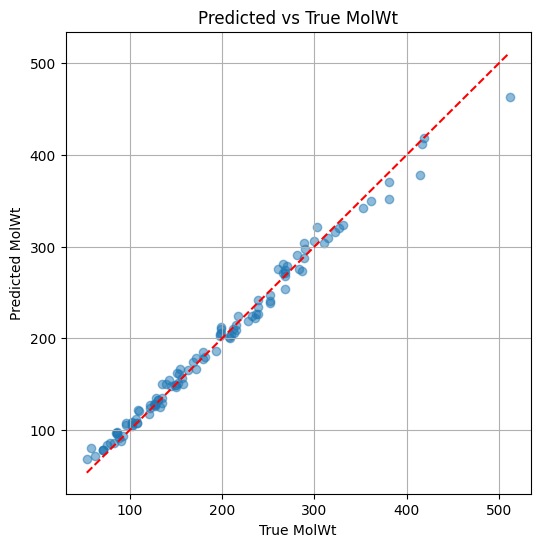

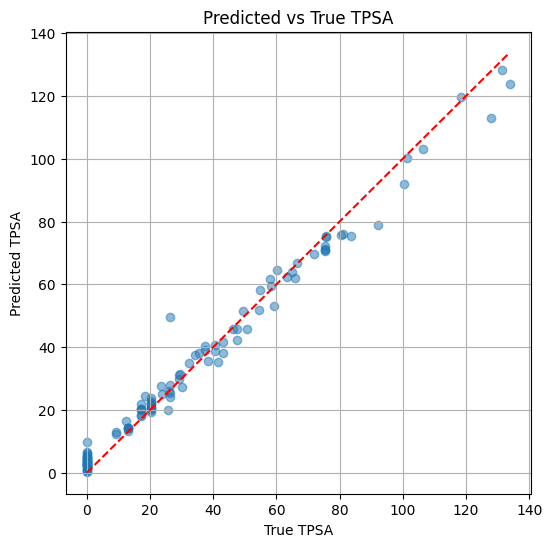

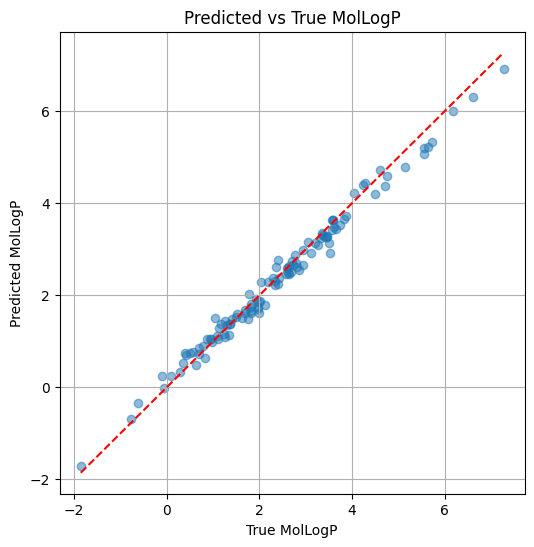

In [ ]:
'''
Scatter plots of predicted vs true values for each property
'''
import matplotlib.pyplot as plt
properties = ['MolWt', 'TPSA', 'MolLogP']
for i, prop in enumerate(properties):
    plt.figure(figsize=(6, 6))
    plt.scatter(targets_denorm[:, i].numpy(), preds_denorm[:, i].numpy(), alpha=0.5)
    plt.plot([targets_denorm[:, i].min(), targets_denorm[:, i].max()], 
             [targets_denorm[:, i].min(), targets_denorm[:, i].max()], 
             'r--')  # Line y=x for reference
    plt.xlabel(f'True {prop}')
    plt.ylabel(f'Predicted {prop}')
    plt.title(f'Predicted vs True {prop}')
    plt.grid()
    plt.show()
